In [1]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity

import matplotlib.pyplot as plt


# ============================================================
# Single-site field operators from ladder operators
# ============================================================

def single_site_field_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Local Hilbert dimension
    # -------------------------------------------------------- 

 
    Nphi = 2**nq   # 64 for nq=6

    # --------------------------------------------------------
    # Ladder operator a
    # --------------------------------------------------------

    a = np.zeros((Nphi, Nphi), dtype=complex)

    for n in range(1, Nphi):

        a[n-1, n] = np.sqrt(n)

    # creation operator
    adag = a.conj().T

    # --------------------------------------------------------
    # Field operator
    #
    # Phi = (a + adag)/sqrt(2 mu)
    # --------------------------------------------------------

    Phi = (
        a + adag
    ) / np.sqrt(2 * mu)

    # --------------------------------------------------------
    # Conjugate momentum operator
    #
    # Pi = -i sqrt(mu/2) (a - adag)
    # --------------------------------------------------------

    Pi = (
        -1j
        * np.sqrt(mu / 2)
        * (a - adag)
    )

    # --------------------------------------------------------
    # Numerical Hermiticity cleanup
    # --------------------------------------------------------

    Phi = 0.5 * (Phi + Phi.conj().T)

    Pi = 0.5 * (Pi + Pi.conj().T)

    return csr_matrix(Phi), csr_matrix(Pi)


# ============================================================
# Two-site embedded operators
# ============================================================

def two_site_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(
        Nphi,
        format='csr',
        dtype=complex
    )

    # --------------------------------------------------------
    # Site 0 operators
    # --------------------------------------------------------

    Phi0 = kron(Phi, I, format='csr')
    Pi0  = kron(Pi,  I, format='csr')

    # --------------------------------------------------------
    # Site 1 operators
    # --------------------------------------------------------

    Phi1 = kron(I, Phi, format='csr')
    Pi1  = kron(I, Pi,  format='csr')

    return Phi0, Pi0, Phi1, Pi1


# ============================================================
# Example
# ============================================================

nq = 4
mu = 1.0

Phi0, Pi0, Phi1, Pi1 = two_site_operators(
    nq,
    mu
)

print("Hilbert dimension =", Phi0.shape[0])

print("Phi0 shape =", Phi0.shape)
print("Pi0 shape  =", Pi0.shape)

print("Phi1 shape =", Phi1.shape)
print("Pi1 shape  =", Pi1.shape)

Hilbert dimension = 256
Phi0 shape = (256, 256)
Pi0 shape  = (256, 256)
Phi1 shape = (256, 256)
Pi1 shape  = (256, 256)


In [2]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity
from scipy.sparse.linalg import eigsh

# ============================================================
# Local single-site Hamiltonian
# ============================================================

def single_site_hloc(Phi, Pi, mI2, lam, f):

    Phi2 = Phi @ Phi
    Phi4 = Phi2 @ Phi2
    Pi2  = Pi @ Pi

    hloc = (
        0.5 * Pi2
        + 0.5 * mI2 * Phi2
        + (lam / 24.0) * Phi4
        + f * Phi
    )

    return hloc




In [3]:
# ============================================================
# Two-site local Hamiltonian
# ============================================================

def two_site_hloc(nq, mu=1.0,
                  mI2=1.0,
                  lam=1.0,
                  f=1e-3):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    # --------------------------------------------------------
    # Single-site local Hamiltonian
    # --------------------------------------------------------

    hloc = single_site_hloc(Phi, Pi, mI2, lam, f)

    # --------------------------------------------------------
    # Two-site Hamiltonian
    # H = h ⊗ I + I ⊗ h
    # --------------------------------------------------------

    Hloc = (
        kron(hloc, I, format='csr')
        +
        kron(I, hloc, format='csr')
    )

    return Hloc




In [4]:
# ============================================================
# Exact ground state
# ============================================================

def ground_state(H):

    # smallest algebraic eigenvalue
    evals, evecs = eigsh(H, k=1, which='SA')

    E0 = evals[0]
    psi0 = evecs[:, 0]

    # normalize explicitly
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0




In [5]:
# ============================================================
# Example
# ============================================================

nq   = 4
mu   = 1.0
mI2  = 1.0
lam  = 1.0
f    = 1e-5

Hloc = two_site_hloc(
    nq=nq,
    mu=mu,
    mI2=mI2,
    lam=lam,
    f=f
)

E0_loc, psi_loc = ground_state(Hloc)

print("Ground-state energy =", E0_loc)
print("State dimension     =", psi_loc.shape)
print("Norm                =", np.linalg.norm(psi_loc))

Ground-state energy = 1.0554722545756907
State dimension     = (256,)
Norm                = 1.0


In [6]:
# ============================================================
# Convert scalar-field Hamiltonian to Pauli form

# ============================================================

from qiskit.quantum_info import Operator, SparsePauliOp

# ============================================================
# Build two-site Hamiltonian
# ============================================================

Hloc = two_site_hloc(
    nq=4,
    mu=1.0,
    mI2=1.0,
    lam=1.0,
    f=1e-5
)

# ============================================================
# Convert sparse matrix -> dense matrix
# ============================================================

H_dense = Hloc.toarray()

print("Dense Hamiltonian shape =", H_dense.shape)

# ============================================================
# Convert to Qiskit Operator
# ============================================================

H_op = Operator(H_dense)

# ============================================================
# Convert to SparsePauliOp
# ============================================================

print("\nConverting to Pauli representation...\n")

H_pauli = SparsePauliOp.from_operator(H_op)

# ============================================================
# Remove tiny coefficients
# ============================================================

H_pauli = H_pauli.simplify(atol=1e-10)

print("Done.")

# ============================================================
# Number of Pauli terms
# ============================================================

print("\nNumber of Pauli terms =", len(H_pauli))

# ============================================================
# Show first few Pauli terms
# ============================================================

print("\nFirst few Pauli terms:\n")

for pauli, coeff in zip(
    H_pauli.paulis[:10],
    H_pauli.coeffs[:10]
):

    print(f"{coeff:.6f} * {pauli}")

Dense Hamiltonian shape = (256, 256)

Converting to Pauli representation...

Done.

Number of Pauli terms = 111

First few Pauli terms:

24.062500+0.000000j * IIIIIIII
0.000019+0.000000j * IIIIIIIX
3.203275+0.000000j * IIIIIIXI
-0.031443+0.000000j * IIIIIIXZ
-0.687500+0.000000j * IIIIIIZI
-0.937500+0.000000j * IIIIIIZZ
0.833067+0.000000j * IIIIIXII
-0.083419+0.000000j * IIIIIXIZ
1.669265+0.000000j * IIIIIXXI
-0.166668+0.000000j * IIIIIXXZ


In [7]:
# ============================================================
# Remove identity offset
# ============================================================

coeffs = H_pauli.coeffs
paulis = H_pauli.paulis

new_coeffs = []
new_paulis = []

identity_shift = 0.0

for p, c in zip(paulis, coeffs):

    if str(p) == 'I' * nq:

        identity_shift += np.real(c)

    else:

        new_paulis.append(p)
        new_coeffs.append(c)

H_pauli_shifted = SparsePauliOp(
    new_paulis,
    coeffs=new_coeffs
)

print("Removed identity shift =", identity_shift)

print("Remaining Pauli terms =",
      len(H_pauli_shifted))

Removed identity shift = 0.0
Remaining Pauli terms = 111


In [18]:
###### Exact Ground State Utility

# ============================================================
# Exact ground state
# ============================================================

def exact_ground_state(H_sparse):

    evals, evecs = eigsh(H_sparse, k=1, which='SA')

    E0 = np.real(evals[0])

    psi0 = evecs[:, 0]
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0


In [19]:
# ============================================================
# H_c
# ============================================================

def two_site_hc(

    nq,

    mu=1.0,

    m0_sq=1.0,

    mI2=1.0
):

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    Phi0 = kron(Phi, I, format='csr')

    Phi1 = kron(I, Phi, format='csr')

    Hc = (

        0.5 * (
            (Phi1 - Phi0) @ (Phi1 - Phi0)
        )

        +

        0.5 * (m0_sq - mI2) * (

            (Phi0 @ Phi0)

            +

            (Phi1 @ Phi1)
        )
    )

    return Hc


In [20]:
# ============================================================
# H_s
# ============================================================

def two_site_hs(

    nq,

    mu=1.0,

    mI2=1.0,

    m0_sq=1.0,

    lam=1.0,

    f=0.0,

    s=1.0
):

    Hloc = two_site_hloc(

        nq=nq,

        mu=mu,

        mI2=mI2,

        lam=lam,

        f=f
    )

    Hc = two_site_hc(

        nq=nq,

        mu=mu,

        m0_sq=m0_sq,

        mI2=mI2
    )

    return Hloc + s * Hc


In [78]:
nq_site = 4

nqubits = 2 * nq_site

mu = 1.0

m0_list=[1.0,2.0,-1.0,-2.0]

# ============================================================
# Parameter sets
# ============================================================

parameter_sets = [

    {
        "label": "Symmetric",
        "mI2": 1.0,
        "f": 0.0
    },
     {
        "label": "Weak SSB",
        "mI2": -1.0,
        "f": 1*1e-5
    },
    {
        "label": "Weak SSB optimised",
        "mI2": -1.0,
        "f": 5*1e-2
    },
   {
        "label": "Strong SSB",
        "mI2": -1.0,
        "f": 0.5
    }
]

# ============================================================
# Lambda scan
# ============================================================

lambda_list = np.linspace(0.1, 2.0, 10)

# ============================================================
# Storage
# ============================================================

all_results = []



def two_site_hs(
    nq,
    mu,
    mI2,
    m0_sq,
    lam,
    f,
    s
):

    Hloc = two_site_hloc(
        nq=nq,
        mu=mu,
        mI2=mI2,
        lam=lam,
        f=f
    )

    Hc = two_site_hc(
        nq=nq,
        mu=mu,
        mI2=mI2,
        m0_sq=m0_sq
    )

    return Hloc + s*Hc




# ============================================================
# Main loop
# ============================================================

all_results = []

for m0_sq in m0_list:

    print("\n")
    print("#"*80)
    print(f"m0² = {m0_sq}")
    print("#"*80)

    # =======================================================
    # Loop over the four physical cases
    # =======================================================

    for params in parameter_sets:

        label = params["label"]
        mI2   = params["mI2"]
        f     = params["f"]

        case_results = []

        # ---------------------------------------------------
        # Loop over lambda
        # ---------------------------------------------------

        for lam in lambda_list:

            # Build total Hamiltonian

            Hs_sparse = two_site_hs(

                nq=nq_site,

                mu=mu,

                mI2=mI2,

                m0_sq=m0_sq,

                lam=lam,

                f=f,

                s=1.0
            )

            # Lowest two eigenstates

            evals, evecs = eigsh(

                Hs_sparse,

                k=2,

                which='SA'
            )

            idx = np.argsort(evals)

            evals = evals[idx]
            evecs = evecs[:, idx]

            E0 = evals[0]
            E1 = evals[1]

            psi0 = evecs[:, 0]
            psi1 = evecs[:, 1]

            gap = E1 - E0

            # Store

            result = {

                "case": label,

                "m0_sq": m0_sq,

                "lambda": lam,

                "mI2": mI2,

                "f": f,

                "E0": E0,

                "E1": E1,

                "gap": gap,

                "psi0": psi0,

                "psi1": psi1
            }

            case_results.append(result)
            all_results.append(result)

        # ===================================================
        # Print ONE summary after all lambda values
        # ===================================================

        print("\n")
        print("="*90)
        print(f"m0² = {m0_sq}      Case = {label}")
        print("="*90)

        print(

            f"{'lambda':<12}"

            f"{'E0':<18}"

            f"{'E1':<18}"

            f"{'Gap':<18}"
        )

        print("-"*90)

        for r in case_results:

            print(

                f"{r['lambda']:<12.4f}"

                f"{r['E0']:<18.10f}"

                f"{r['E1']:<18.10f}"

                f"{r['gap']:<18.10f}"
            )



################################################################################
m0² = 1.0
################################################################################


m0² = 1.0      Case = Symmetric
lambda      E0                E1                Gap               
------------------------------------------------------------------------------------------
0.1000      1.3698805190      2.3795897301      1.0097092111      
0.3111      1.3778182555      2.4071288286      1.0293105731      
0.5222      1.3855077234      2.4333626999      1.0478549765      
0.7333      1.3929736049      2.4584667213      1.0654931164      
0.9444      1.4002363572      2.4825780373      1.0823416801      
1.1556      1.4073132214      2.5058067351      1.0984935137      
1.3667      1.4142189288      2.5282430329      1.1140241041      
1.5778      1.4209662109      2.5499621250      1.1289959141      
1.7889      1.4275661795      2.5710275723      1.1434613928      
2.0000      1.4340286146      2

In [46]:
# ============================================================
# Exact ground state
# ============================================================

def exact_ground_state(H):

    H_dense = H.toarray()

    eigvals, eigvecs = np.linalg.eigh(H_dense)

    return eigvals[0], eigvecs[:, 0]

In [47]:
# ============================================================
# Minimum instantaneous gap along adiabatic path
# ============================================================

def minimum_gap_along_path(

    nq,

    mu,

    mI2,

    m0_sq,

    lam,
    
    f,

    nsteps=100
):

    gap_min = 1e100

    for step in range(nsteps):

        s = step / nsteps

        Hs = two_site_hs(

            nq=nq,

            mu=mu,

            mI2=mI2,

            m0_sq=m0_sq,

            lam=lam,

            f=f,

            s=s
        )

        evals, _ = eigsh(

            Hs,

            k=2,

            which='SA'
        )

        evals = np.sort(np.real(evals))

        gap = evals[1] - evals[0]

        gap_min = min(gap_min, gap)

    return gap_min

In [39]:
# ============================================================
# Order parameter operator
# ============================================================

Phi0, Pi0, Phi1, Pi1 = two_site_operators(

    nq_site,

    mu
)

Phi_avg = 0.5 * (Phi0 + Phi1)

In [79]:
phi_results = []

for r in all_results:

    M = np.real(

        np.vdot(

            r["psi0"],

            Phi_avg @ r["psi0"]
        )
    )

    phi_results.append({

        "case": r["case"],

        "m0_sq": r["m0_sq"],

        "lambda": r["lambda"],

        "phi": M
    })

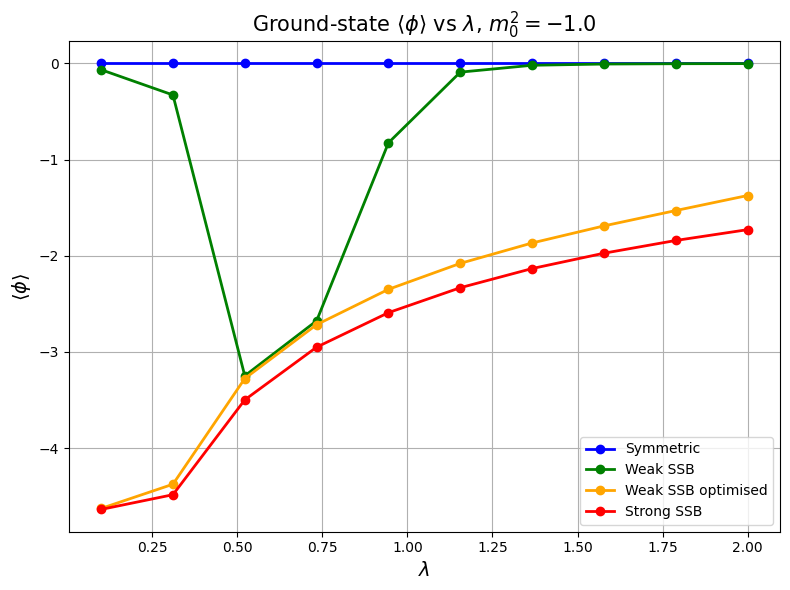

In [80]:
#****<phi>*******

import matplotlib.pyplot as plt

m0_value = -1.0

case_colors = {
    "Symmetric": "blue",
    "Weak SSB": "green",
    "Weak SSB optimised": "orange",
    "Strong SSB": "red"
}

plt.figure(figsize=(8,6))

for case in case_colors:

    lam = []
    phi = []

    for r in phi_results:

        if r["m0_sq"] == m0_value and r["case"] == case:

            lam.append(r["lambda"])
            phi.append(r["phi"])

    plt.plot(
        lam,
        phi,
        marker='o',
        linewidth=2,
        color=case_colors[case],
        label=case
    )

plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\langle\phi\rangle$', fontsize=14)

plt.title(
    rf'Ground-state $\langle\phi\rangle$ vs $\lambda$, $m_0^2={m0_value}$',
    fontsize=15
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

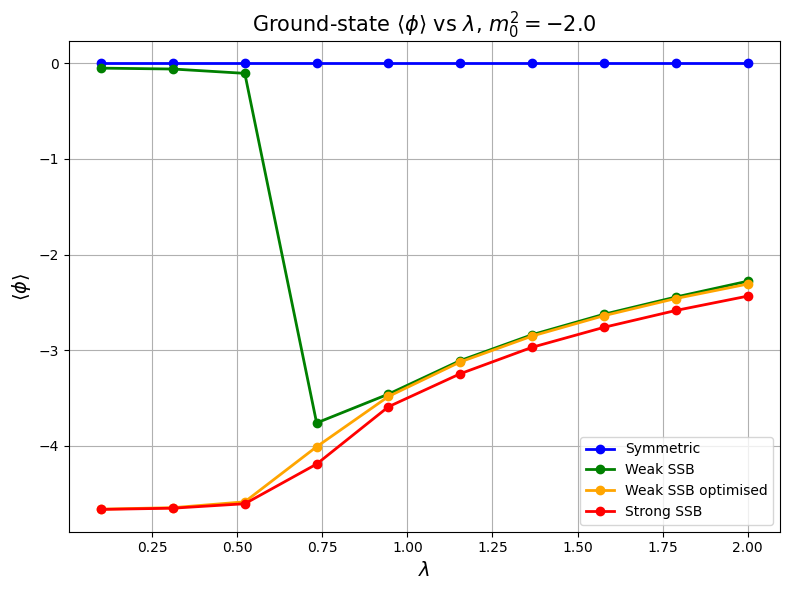

In [81]:
import matplotlib.pyplot as plt

m0_value = -2.0

case_colors = {
    "Symmetric": "blue",
    "Weak SSB": "green",
    "Weak SSB optimised": "orange",
    "Strong SSB": "red"
}

plt.figure(figsize=(8,6))

for case in case_colors:

    lam = []
    phi = []

    for r in phi_results:

        if r["m0_sq"] == m0_value and r["case"] == case:

            lam.append(r["lambda"])
            phi.append(r["phi"])

    plt.plot(
        lam,
        phi,
        marker='o',
        linewidth=2,
        color=case_colors[case],
        label=case
    )

plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\langle\phi\rangle$', fontsize=14)

plt.title(
    rf'Ground-state $\langle\phi\rangle$ vs $\lambda$, $m_0^2={m0_value}$',
    fontsize=15
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

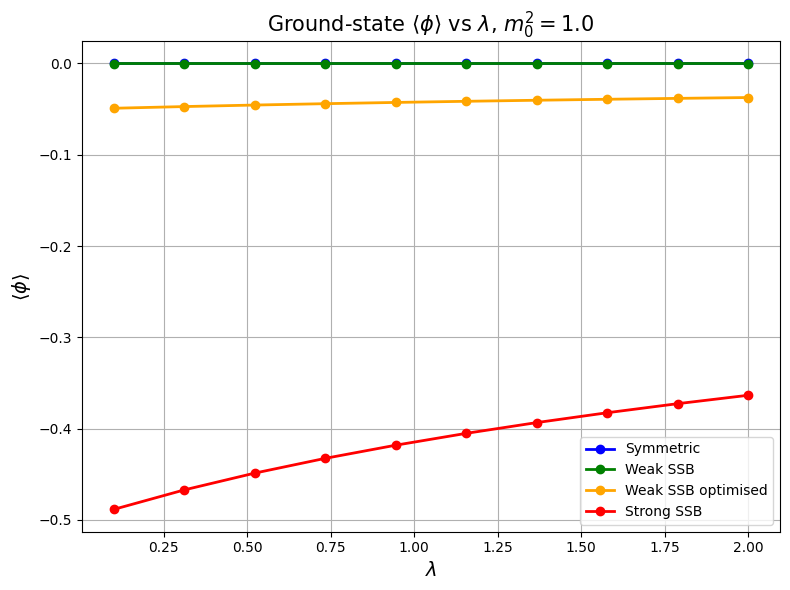

In [82]:
import matplotlib.pyplot as plt

m0_value = 1.0

case_colors = {
    "Symmetric": "blue",
    "Weak SSB": "g",
    "Weak SSB optimised": "orange",
    "Strong SSB": "red"
}

plt.figure(figsize=(8,6))

for case in case_colors:

    lam = []
    phi = []

    for r in phi_results:

        if r["m0_sq"] == m0_value and r["case"] == case:

            lam.append(r["lambda"])
            phi.append(r["phi"])

    plt.plot(
        lam,
        phi,
        marker='o',
        linewidth=2,
        color=case_colors[case],
        label=case
    )

plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\langle\phi\rangle$', fontsize=14)

plt.title(
    rf'Ground-state $\langle\phi\rangle$ vs $\lambda$, $m_0^2={m0_value}$',
    fontsize=15
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

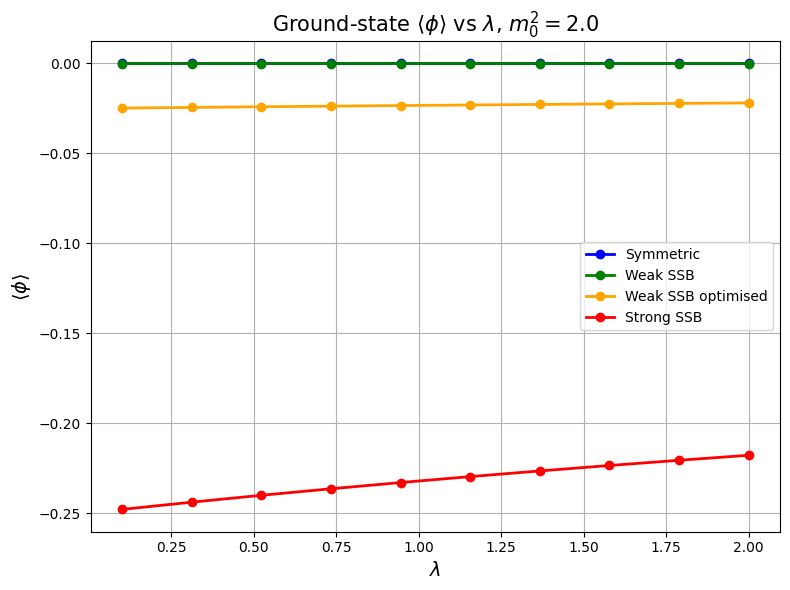

In [83]:
import matplotlib.pyplot as plt

m0_value = 2.0

case_colors = {
    "Symmetric": "blue",
    "Weak SSB": "g",
    "Weak SSB optimised": "orange",
    "Strong SSB": "red"
}

plt.figure(figsize=(8,6))

for case in case_colors:

    lam = []
    phi = []

    for r in phi_results:

        if r["m0_sq"] == m0_value and r["case"] == case:

            lam.append(r["lambda"])
            phi.append(r["phi"])

    plt.plot(
        lam,
        phi,
        marker='o',
        linewidth=2,
        color=case_colors[case],
        label=case
    )

plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\langle\phi\rangle$', fontsize=14)

plt.title(
    rf'Ground-state $\langle\phi\rangle$ vs $\lambda$, $m_0^2={m0_value}$',
    fontsize=15
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [84]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

import numpy as np

phi_data = {}

for r in phi_results:

    key = (r["m0_sq"], r["case"])

    if key not in phi_data:
        phi_data[key] = {
            "lambda": [],
            "phi": []
        }

    phi_data[key]["lambda"].append(r["lambda"])
    phi_data[key]["phi"].append(r["phi"])

[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]


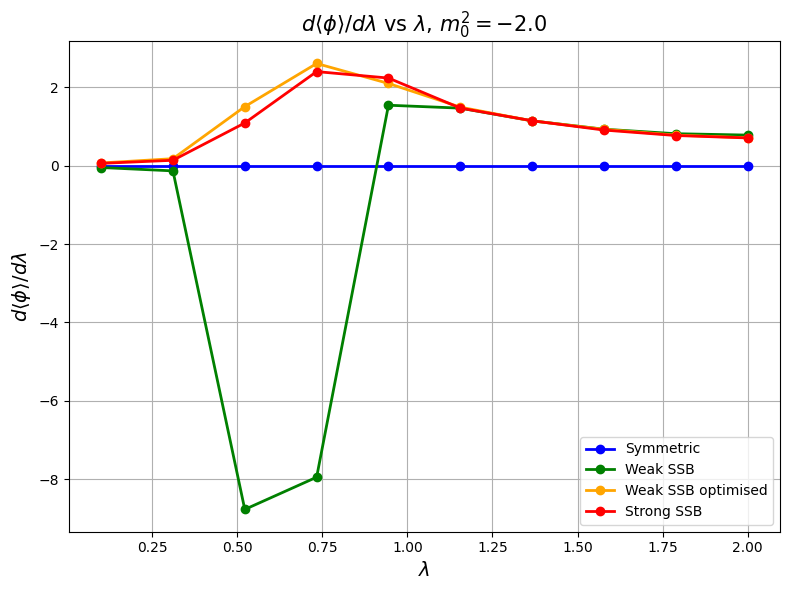

[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]


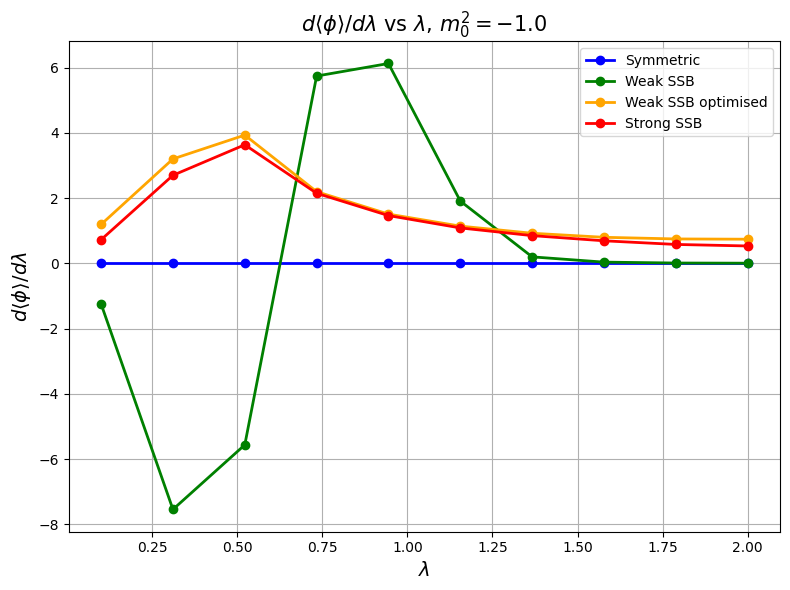

[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]


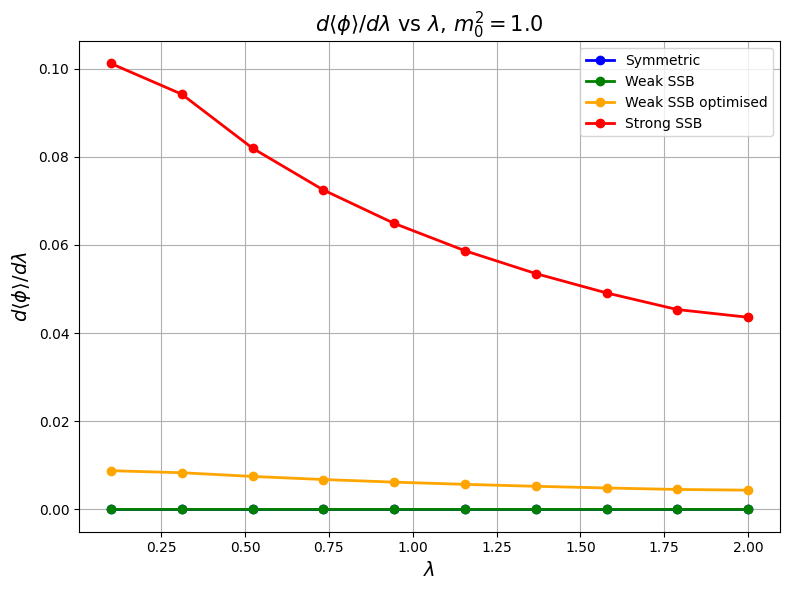

[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]
[0.1        0.31111111 0.52222222 0.73333333 0.94444444 1.15555556
 1.36666667 1.57777778 1.78888889 2.        ]


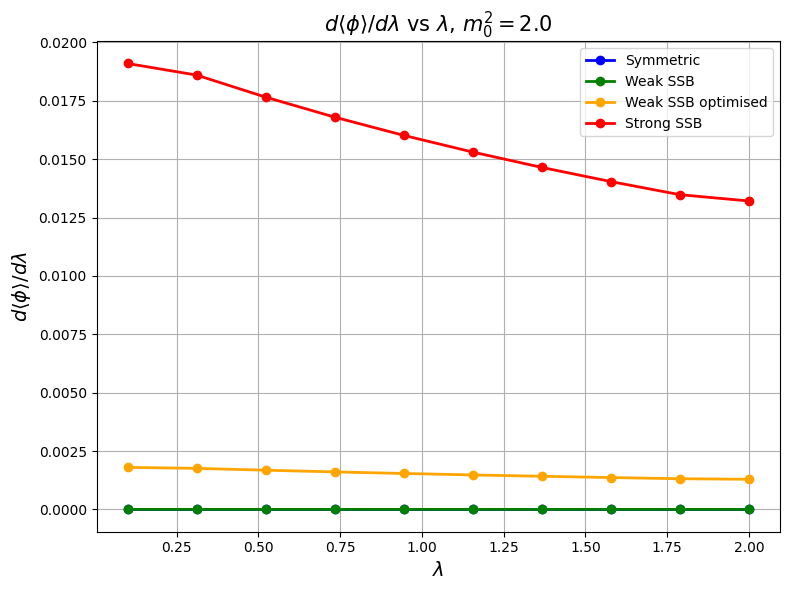

In [86]:
import matplotlib.pyplot as plt

case_colors = {

    "Symmetric": "blue",

    "Weak SSB": "green",

    "Weak SSB optimised": "orange",

    "Strong SSB": "red"
}

for m0_value in [-2.0, -1.0, 1.0, 2.0]:

    plt.figure(figsize=(8,6))

    for case in case_colors:

        key = (m0_value, case)

        if key not in phi_data:
            continue

        lam = np.array(phi_data[key]["lambda"])
        phi = np.array(phi_data[key]["phi"])

        # Sort by lambda
        idx = np.argsort(lam)

        lam = lam[idx]
        phi = phi[idx]

        print(lam)

        # First derivative

        dphi = np.gradient(phi, lam)

        plt.plot(

            lam,

            dphi,

            marker='o',

            linewidth=2,

            color=case_colors[case],

            label=case
        )

    plt.xlabel(r'$\lambda$', fontsize=14)

    plt.ylabel(r'$d\langle\phi\rangle/d\lambda$', fontsize=14)

    plt.title(

        rf'$d\langle\phi\rangle/d\lambda$ vs $\lambda$, $m_0^2={m0_value}$',

        fontsize=15
    )

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.savefig(

        f"dphi_dlambda_m0_{m0_value}.pdf",

        bbox_inches="tight"
    )

    plt.show()

In [40]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

phi_data = {}

for r in all_results:

    key = (r["m0_sq"], r["case"])

    if key not in phi_data:

        phi_data[key] = {
            "lambda": [],
            "phi": []
        }

    phi_data[key]["lambda"].append(r["lambda"])
    phi_data[key]["phi"].append(r["phi"])

for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    Tmin = r['Tmin']

    mI2 = r['mI2']

    f = r['f']

    match = next(
        x for x in all_results
        if (
            x['case'] == case
            and np.isclose(x['lambda'], lam)
        )
    )

   # Exact ground state of H_loc
    psi_exact = match['psi_exact']

# Adiabatic evolution starts from the exact local ground state
    psi_final = adiabatic_circuit_evolution(

        initial_state=psi_exact,

        nq=nq_site,

        T=Tmin,

        mu=mu,

        mI2=mI2,

        m0_sq=1.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    M = np.real(

        np.vdot(

            psi_final,

            Phi_avg @ psi_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)

    elif case == "Strong SSB":

        M_strong.append(M)

NameError: name 'adiabatic_results' is not defined

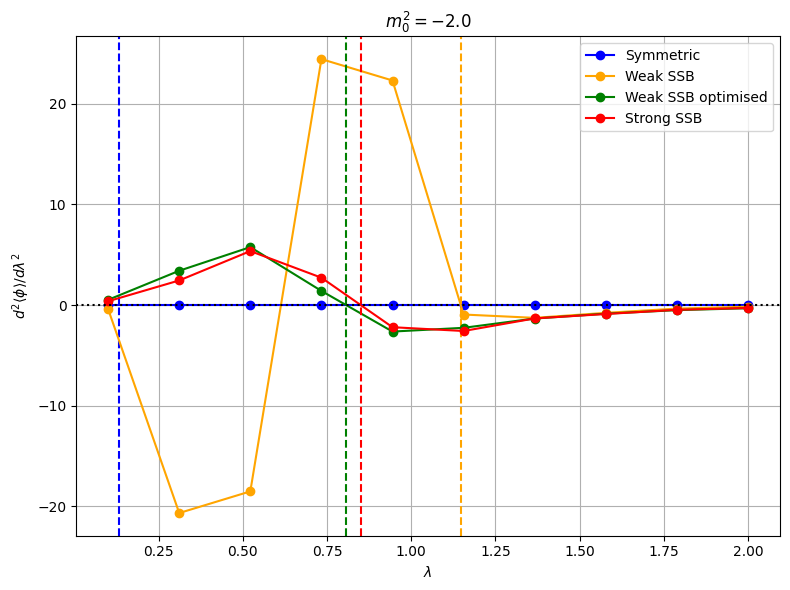

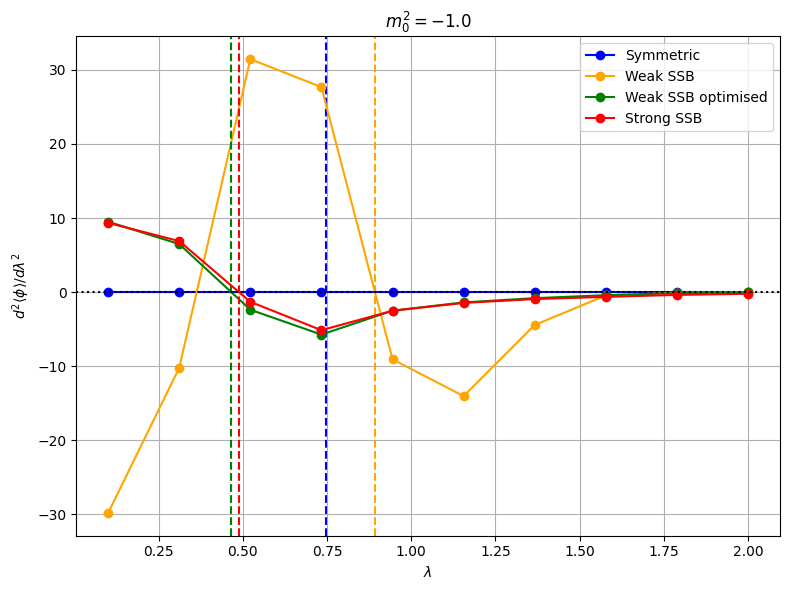

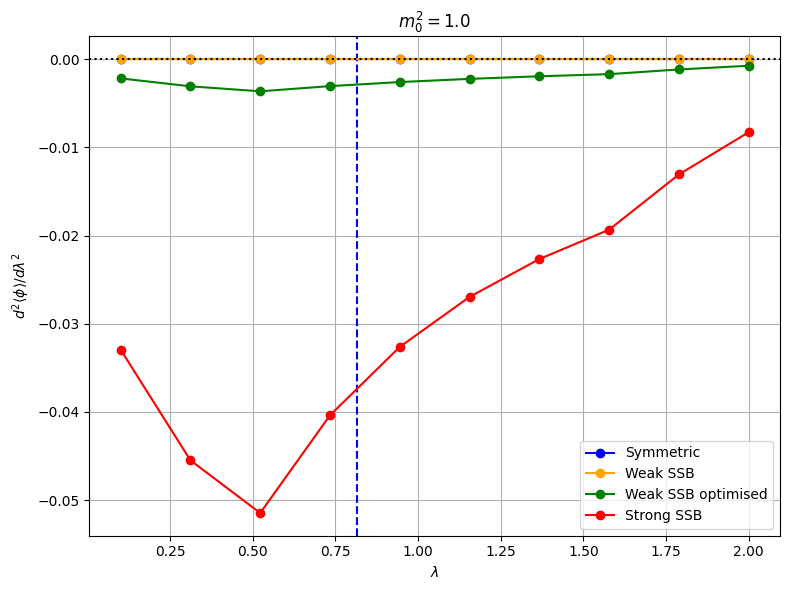

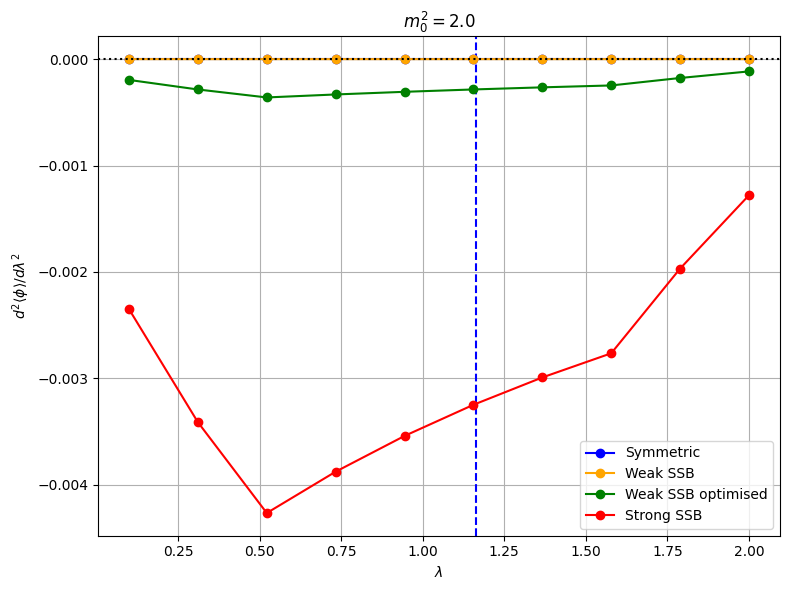

In [90]:
# ============================================================
# λc from inflection point
# ============================================================

derivatives = {}

for key, data in phi_data.items():

    lam = np.array(data["lambda"])
    phi = np.array(data["phi"])

    order = np.argsort(lam)

    lam = lam[order]
    phi = phi[order]

    d1 = np.gradient(phi, lam)

    d2 = np.gradient(d1, lam)

    d3 = np.gradient(d2, lam)

    derivatives[key] = {

        "lambda": lam,

        "d2": d2,

        "d3": d3
    }

def find_lambda_c(lams, d2M, d3M):

    for i in range(len(lams)-1):

        if d2M[i] * d2M[i+1] <= 0:

            if d3M[i] < 0:

                x1 = lams[i]
                x2 = lams[i+1]

                y1 = d2M[i]
                y2 = d2M[i+1]

                return x1 - y1*(x2-x1)/(y2-y1)
    return np.nan

lambda_c = {}

for key, data in derivatives.items():

    lambda_c[key] = find_lambda_c(

        data["lambda"],

        data["d2"],

        data["d3"]
    )


########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

case_colors = {

    "Symmetric": "blue",

    "Weak SSB": "orange",

    "Weak SSB optimised": "green",

    "Strong SSB": "red"
}

for m0 in sorted(set(r["m0_sq"] for r in all_results)):

    plt.figure(figsize=(8,6))

    for case in case_colors:

        key = (m0, case)

        if key not in derivatives:

            continue

        lam = derivatives[key]["lambda"]

        d2 = derivatives[key]["d2"]

        lamc = lambda_c[key]

        line, = plt.plot(

            lam,

            d2,

            'o-',

            color=case_colors[case],

            label=case
        )

        if not np.isnan(lamc):

            plt.axvline(

                lamc,

                linestyle='--',

                color=line.get_color()
            )

    plt.axhline(

        0,

        color='k',

        linestyle=':'
    )

    plt.xlabel(r'$\lambda$')

    plt.ylabel(

        r'$d^2\langle\phi\rangle/d\lambda^2$'
    )

    plt.title(

        rf'$m_0^2={m0}$'
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [43]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    dM_sym,
    'o-',
    label='Symmetric',
    color='b'
)

line2, = plt.plot(
    lambda_list,
    dM_weak,
    's-',
    label='Weak SSB optimised',
    color='g'
)

line3, = plt.plot(
    lambda_list,
    dM_strong,
    '^-',
    label='Strong SSB',
    color='r'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_0^2=1$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'dM_sym' is not defined

<Figure size 800x600 with 0 Axes>

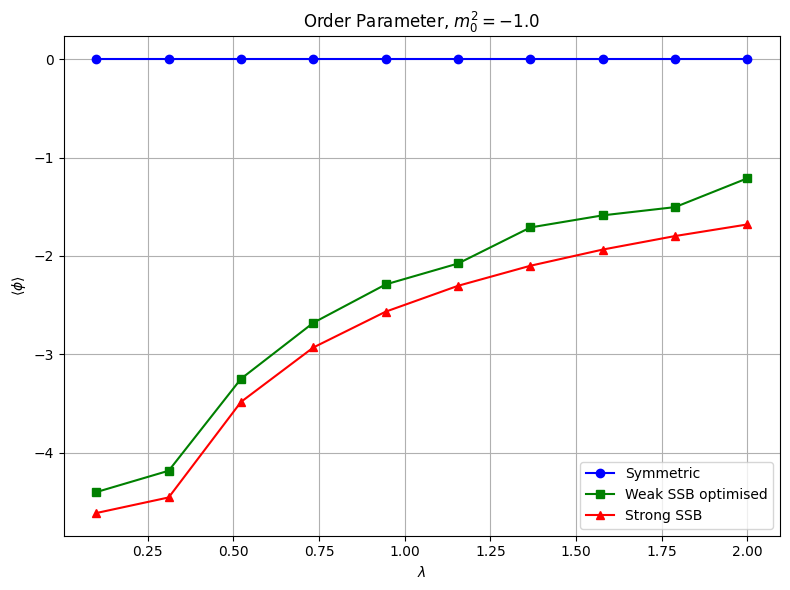

In [44]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_sym,

    M_sym,

    'o-',

    label='Symmetric',
    color='b'
)

plt.plot(

    lambda_weak_opt,

    M_weak_opt,

    's-',

    label='Weak SSB optimised',
    color='g'
)

plt.plot(

    lambda_strong,

    M_strong,

    '^-',

    label='Strong SSB',
    color='r'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title(r'Order Parameter, $m_{0}^{2}=-1.0$')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

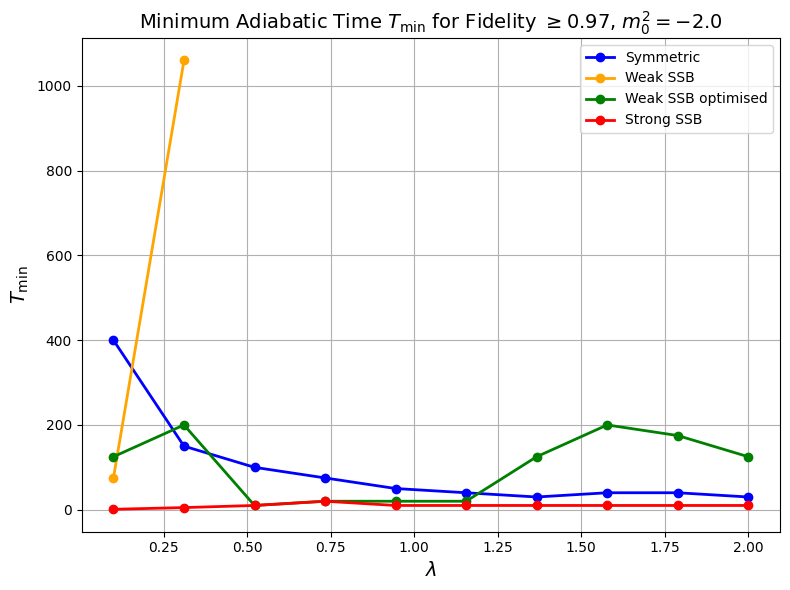

In [49]:
# ============================================================
# Plot T_min vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# Separate data by case
# ============================================================

case_data = {}

for r in adiabatic_results:

    case = r['case']

    if case not in case_data:

        case_data[case] = {

            'lambda': [],

            'Tmin': []
        }

    case_data[case]['lambda'].append(

        r['lambda']
    )

    case_data[case]['Tmin'].append(

        r['Tmin']
    )

# ============================================================
# Plot
# ============================================================
case_colors = {
    "Symmetric": "blue",
    "Weak SSB": "orange",
    "Weak SSB optimised": "green",
    "Strong SSB": "red"
}
#

plt.figure(figsize=(8,6))

for case, d in case_data.items():

    plt.plot(

        d['lambda'],

        d['Tmin'],

        marker='o',

        linewidth=2,
        
        color=case_colors[case],

        label=case
    )

# ============================================================
# Labels
# ============================================================

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$T_{\min}$', fontsize=14)

plt.title(

    r'Minimum Adiabatic Time $T_{\min}$ '
    r'for Fidelity $\geq 0.97$, $m_{0}^{2}=-2.0$',

    fontsize=14
)

plt.grid(True)

plt.legend()

plt.tight_layout()
plt.savefig(
    "HEA_adiabatic time vs lambda.pdf",
    bbox_inches='tight'
)
plt.show()

In [52]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []
lambda_sym = []
lambda_weak_opt = []
lambda_strong = []
for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    Tmin = r['Tmin']
    # Skip if no Tmin was found

    if Tmin is None:
        continue

    if np.isnan(Tmin):
        continue

    mI2 = r['mI2']

    f = r['f']

    match = next(
        x for x in all_results
        if (
            x['case'] == case
            and np.isclose(x['lambda'], lam)
        )
    )

    psi_exact = match['psi_exact']

    psi_final = adiabatic_circuit_evolution(

        initial_state=psi_exact,

        nq=nq_site,

        T=Tmin,

        mu=mu,

        mI2=mI2,

        m0_sq=-2.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    M = np.real(

        np.vdot(

            psi_final,

            Phi_avg @ psi_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)
        lambda_sym.append(lam)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)
        lambda_weak_opt.append(lam)

    elif case == "Strong SSB":

        M_strong.append(M)
        lambda_strong.append(lam)

dict_keys(['case', 'lambda', 'mI2', 'f', 'Tmin', 'best_fidelity', 'delta_min', 'P0', 'P1', 'P01', 'final_gap'])
